# NB05: AMR Ecotypes

**Goal**: Cluster genomes by AMR profile within each species. Test whether
AMR-defined clusters (ecotypes) segregate by environment.

**Compute**: Local (20-40 min)

**Inputs**: `data/genome_amr_matrices/*.tsv`, `data/genome_metadata.csv`

**Outputs**:
- `data/amr_ecotypes.csv` — per-genome ecotype assignments
- UMAP + heatmap figures for case study species

In [1]:
import os
import pandas as pd
import numpy as np
from pathlib import Path
from scipy import stats
from scipy.spatial.distance import pdist, squareform
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import umap

from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score

PROJECT_DIR = Path(os.getcwd()).parent
ATLAS_DIR = PROJECT_DIR.parent / 'amr_pangenome_atlas'
DATA_DIR = PROJECT_DIR / 'data'
MATRIX_DIR = DATA_DIR / 'genome_amr_matrices'
FIG_DIR = PROJECT_DIR / 'figures'
FIG_DIR.mkdir(exist_ok=True)

plt.rcParams.update({'figure.dpi': 150, 'font.size': 10})

## 1. Load Metadata

In [2]:
genome_meta = pd.read_csv(DATA_DIR / 'genome_metadata.csv')
print(f"Genome metadata: {len(genome_meta)} genomes")

def classify_environment(isolation_source, host=None):
    """Classify environment from NCBI isolation_source and host fields."""
    env = str(isolation_source).lower() if pd.notna(isolation_source) else ''
    h = str(host).lower() if pd.notna(host) else ''
    
    # Human clinical
    if any(k in env for k in ['blood', 'sputum', 'urine', 'wound', 'abscess',
                               'clinical', 'hospital', 'patient']):
        return 'Human-Clinical'
    if 'homo sapiens' in h or 'human' in h:
        if any(k in env for k in ['stool', 'feces', 'gut', 'intestin', 'rectal']):
            return 'Human-Gut'
        return 'Human-Other'
    
    # Animal
    if any(k in env for k in ['chicken', 'poultry', 'swine', 'pig', 'cattle',
                               'bovine', 'livestock', 'animal']):
        return 'Animal'
    if any(k in h for k in ['gallus', 'sus scrofa', 'bos taurus', 'canis']):
        return 'Animal'
    
    # Food
    if any(k in env for k in ['food', 'meat', 'milk', 'cheese', 'lettuce', 'produce']):
        return 'Food'
    
    # Water
    if any(k in env for k in ['water', 'river', 'lake', 'sewage', 'wastewater',
                               'marine', 'ocean', 'aquatic']):
        return 'Water'
    
    # Soil / Environment
    if any(k in env for k in ['soil', 'rhizosphere', 'root', 'plant', 'leaf']):
        return 'Soil/Plant'
    
    return 'Unknown'

genome_meta['environment'] = genome_meta.apply(
    lambda r: classify_environment(r.get('isolation_source'), r.get('host')), axis=1
)
env_counts = genome_meta['environment'].value_counts()
print(f"\nEnvironment classification:")
print(env_counts)

Genome metadata: 180025 genomes



Environment classification:
environment
Unknown           94957
Human-Other       32464
Human-Clinical    22278
Human-Gut         10704
Animal             6645
Soil/Plant         5155
Water              4388
Food               3434
Name: count, dtype: int64


## 2. Ecotype Detection Pipeline

In [3]:
def detect_ecotypes(matrix, min_cluster_size=5):
    """Cluster genomes by AMR profile using UMAP + DBSCAN on Jaccard distance."""
    n_genomes = matrix.shape[0]
    
    if n_genomes < 15:
        return None, None, None
    
    # Compute Jaccard distance
    jaccard_dist = squareform(pdist(matrix.values, metric='jaccard'))
    
    # Handle constant rows (all-same AMR profile)
    if np.all(jaccard_dist == 0):
        return None, None, None
    
    # UMAP embedding (2D) from precomputed distance
    n_neighbors = min(15, n_genomes - 1)
    reducer = umap.UMAP(
        n_components=2,
        metric='precomputed',
        n_neighbors=n_neighbors,
        min_dist=0.1,
        random_state=42
    )
    embedding = reducer.fit_transform(jaccard_dist)
    
    # DBSCAN on Jaccard distance
    # Estimate eps from distance distribution
    upper_tri = jaccard_dist[np.triu_indices(n_genomes, k=1)]
    eps = np.percentile(upper_tri[upper_tri > 0], 25) if (upper_tri > 0).any() else 0.3
    eps = max(eps, 0.05)  # minimum eps
    
    clusterer = DBSCAN(eps=eps, min_samples=min_cluster_size, metric='precomputed')
    labels = clusterer.fit_predict(jaccard_dist)
    
    n_clusters = len(set(labels) - {-1})
    
    # Compute silhouette if we have clusters
    sil = np.nan
    if n_clusters >= 2:
        non_noise = labels != -1
        if non_noise.sum() >= n_clusters + 1:
            sil = silhouette_score(jaccard_dist[non_noise][:, non_noise],
                                   labels[non_noise], metric='precomputed')
    
    return embedding, labels, sil

## 3. Process All Species

In [4]:
matrix_files = sorted(MATRIX_DIR.glob('*.tsv'))
print(f"Processing {len(matrix_files)} species...")

ecotype_rows = []
species_ecotype_summary = []

for idx, mf in enumerate(matrix_files):
    species_id = mf.stem
    matrix = pd.read_csv(mf, sep='\t', index_col=0)
    
    if matrix.shape[0] < 15 or matrix.shape[1] < 3:
        continue
    
    embedding, labels, sil = detect_ecotypes(matrix)
    
    if embedding is None:
        continue
    
    n_clusters = len(set(labels) - {-1})
    
    # Record per-genome ecotype
    for i, genome_id in enumerate(matrix.index):
        ecotype_rows.append({
            'gtdb_species_clade_id': species_id,
            'genome_id': genome_id,
            'ecotype': labels[i],
            'umap_x': embedding[i, 0],
            'umap_y': embedding[i, 1],
        })
    
    species_ecotype_summary.append({
        'gtdb_species_clade_id': species_id,
        'n_genomes': matrix.shape[0],
        'n_clusters': n_clusters,
        'silhouette': sil,
        'noise_frac': (labels == -1).mean(),
    })
    
    if (idx + 1) % 100 == 0:
        print(f"  [{idx+1}/{len(matrix_files)}]")

ecotype_df = pd.DataFrame(ecotype_rows)
eco_summary = pd.DataFrame(species_ecotype_summary)

print(f"\nEcotype assignments: {len(ecotype_df)} genomes")
print(f"Species with clusters: {(eco_summary['n_clusters'] >= 2).sum()}/{len(eco_summary)}")

Processing 1305 species...


  [100/1305]


  [300/1305]


  [500/1305]


  [900/1305]


  [1000/1305]


  [1100/1305]


  [1300/1305]



Ecotype assignments: 176177 genomes
Species with clusters: 190/974


## 4. Environment Segregation Test

In [5]:
# Merge ecotypes with metadata
ecotype_meta = ecotype_df.merge(genome_meta[['genome_id', 'environment']], on='genome_id', how='left')

# Chi-squared test per species: do ecotypes segregate by environment?
env_tests = []

for species_id, grp in ecotype_meta.groupby('gtdb_species_clade_id'):
    # Exclude noise and Unknown environment
    valid = grp[(grp['ecotype'] >= 0) & (grp['environment'] != 'Unknown')]
    
    if valid['ecotype'].nunique() < 2 or valid['environment'].nunique() < 2:
        continue
    
    ct = pd.crosstab(valid['ecotype'], valid['environment'])
    
    # Need sufficient total counts
    if ct.values.sum() < 20:
        continue
    
    # Check expected frequencies: chi-squared requires most expected cells >= 5
    chi2, p, dof, expected = stats.chi2_contingency(ct)
    if (expected < 5).sum() > 0.2 * expected.size:
        # More than 20% of expected cells < 5 — chi-squared unreliable, skip
        continue
    
    # Cramér's V
    n = ct.values.sum()
    k = min(ct.shape) - 1
    cramers_v = np.sqrt(chi2 / (n * k)) if k > 0 and n > 0 else 0
    
    env_tests.append({
        'gtdb_species_clade_id': species_id,
        'n_ecotypes': valid['ecotype'].nunique(),
        'n_environments': valid['environment'].nunique(),
        'n_genomes': len(valid),
        'chi2': chi2,
        'p_value': p,
        'cramers_v': cramers_v,
    })

env_test_df = pd.DataFrame(env_tests)

if len(env_test_df) > 0:
    from statsmodels.stats.multitest import multipletests
    _, fdr, _, _ = multipletests(env_test_df['p_value'], method='fdr_bh')
    env_test_df['fdr'] = fdr
    
    sig = (env_test_df['fdr'] < 0.05).sum()
    print(f"Species with significant env-ecotype association: {sig}/{len(env_test_df)}")
    print(f"Median Cramér's V: {env_test_df['cramers_v'].median():.3f}")
else:
    print("No species had enough data for env-ecotype tests.")

Species with significant env-ecotype association: 1/2
Median Cramér's V: 0.070


## 5. Case Study Species

In [6]:
# Case study species (search by name fragment)
case_study_targets = [
    'Klebsiella_pneumoniae',
    'Escherichia_coli',
    'Staphylococcus_aureus',
    'Pseudomonas_aeruginosa',
    'Salmonella_enterica',
    'Acinetobacter_baumannii',
]

all_species = [mf.stem for mf in matrix_files]

case_studies = {}
for target in case_study_targets:
    matches = [s for s in all_species if target in s]
    if matches:
        case_studies[target] = matches[0]
        print(f"{target} -> {matches[0]}")
    else:
        print(f"{target} -> NOT FOUND")

Klebsiella_pneumoniae -> s__Klebsiella_pneumoniae--RS_GCF_000742135.1
Escherichia_coli -> NOT FOUND
Staphylococcus_aureus -> s__Staphylococcus_aureus--RS_GCF_001027105.1
Pseudomonas_aeruginosa -> s__Pseudomonas_aeruginosa--RS_GCF_001457615.1
Salmonella_enterica -> s__Salmonella_enterica--RS_GCF_000006945.2
Acinetobacter_baumannii -> s__Acinetobacter_baumannii--RS_GCF_009759685.1


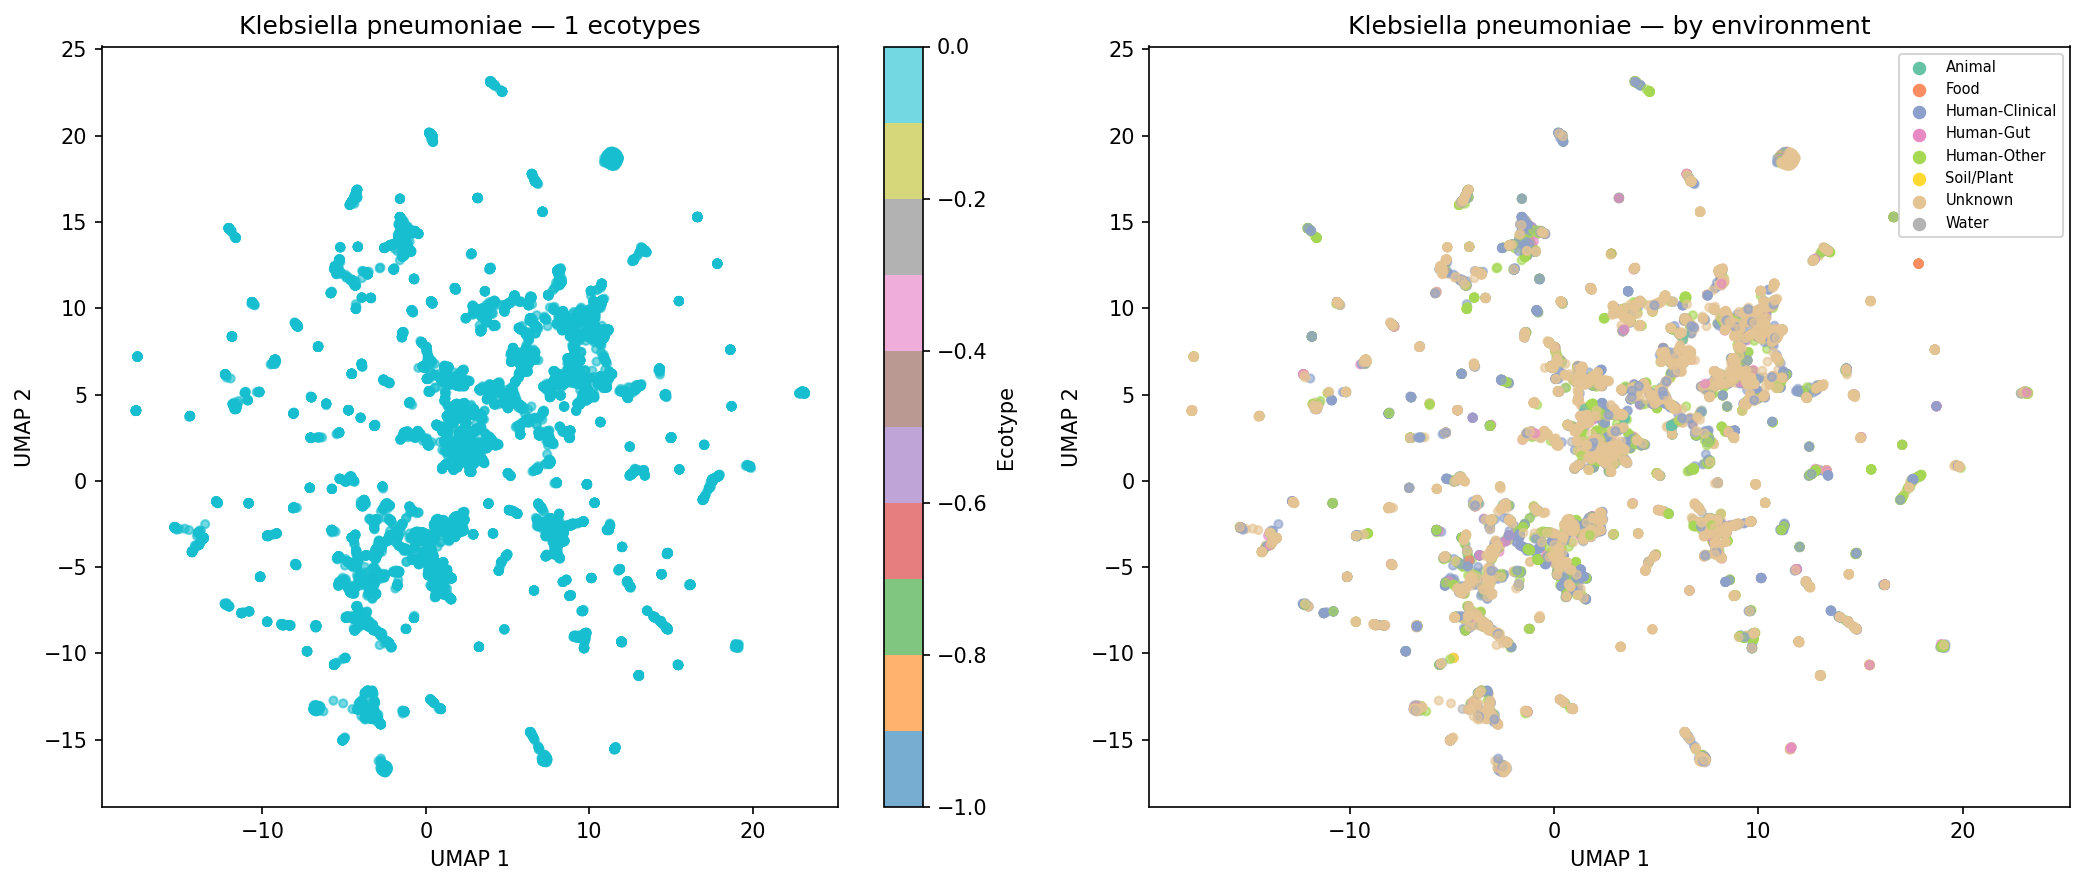

Klebsiella_pneumoniae: 14240 genomes, 1 ecotypes


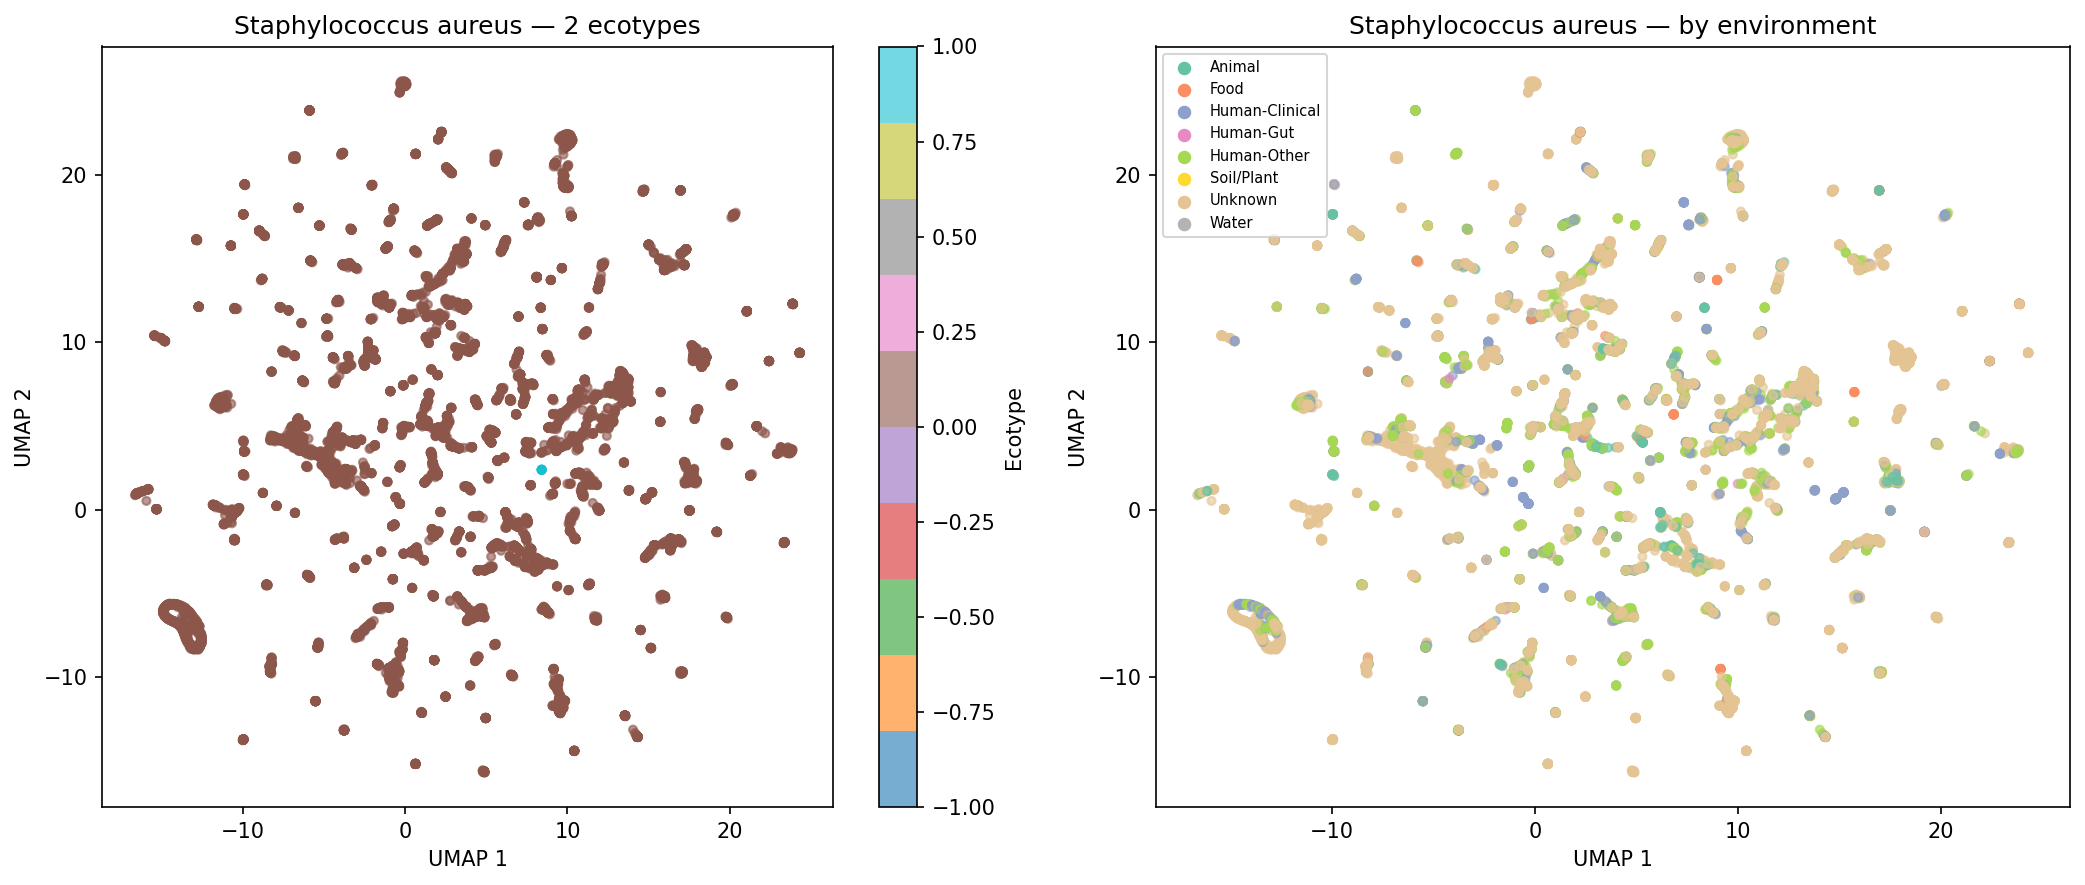

Staphylococcus_aureus: 14526 genomes, 2 ecotypes, silhouette=0.242


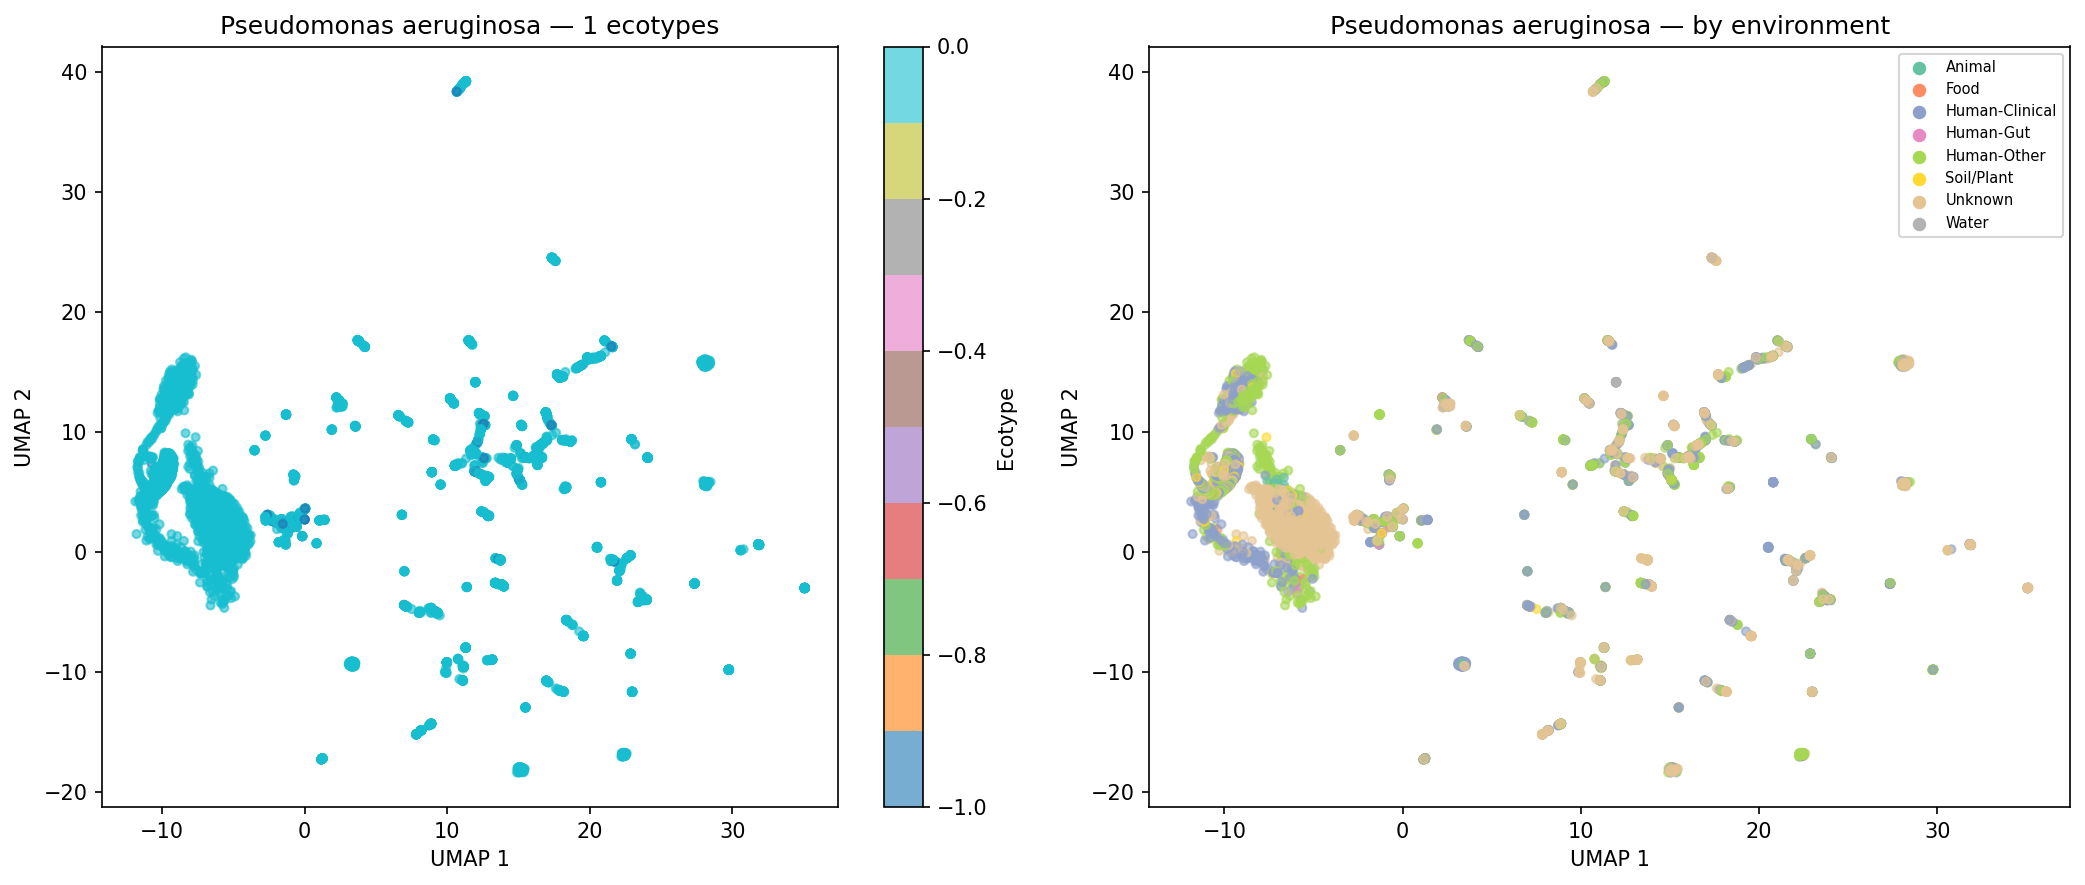

Pseudomonas_aeruginosa: 6760 genomes, 1 ecotypes


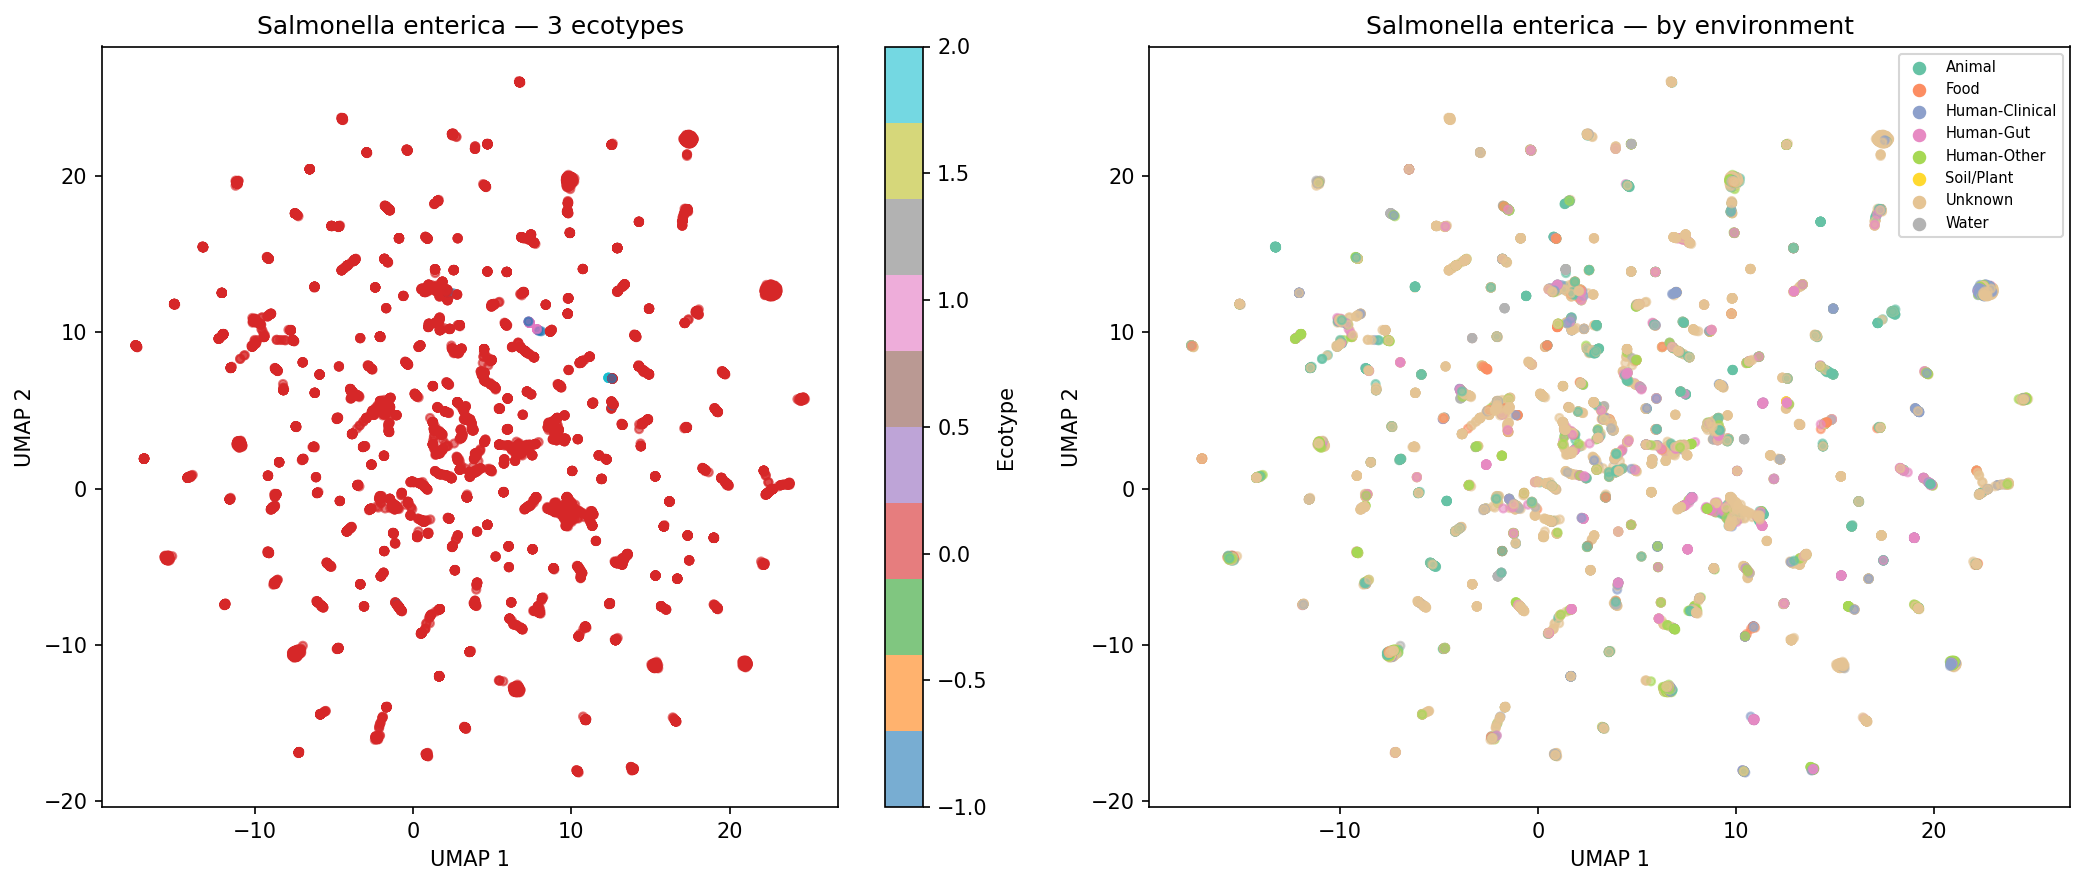

Salmonella_enterica: 11402 genomes, 3 ecotypes, silhouette=0.238


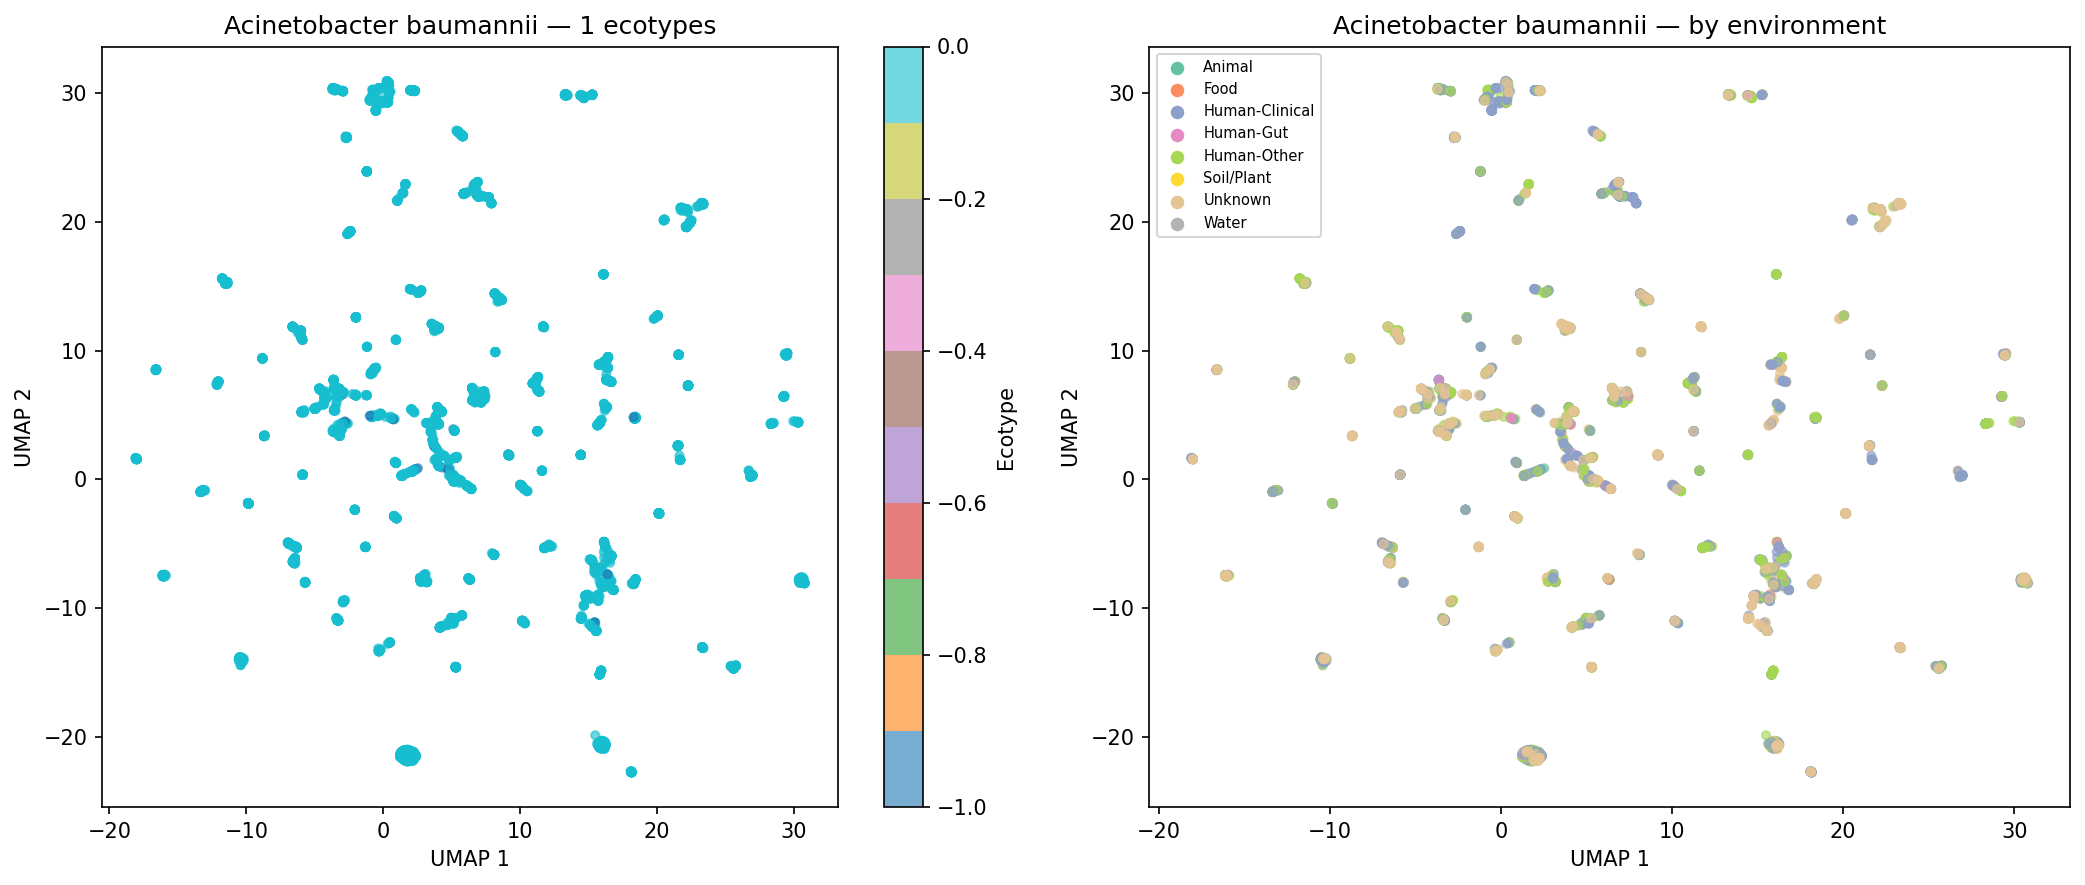

Acinetobacter_baumannii: 6647 genomes, 1 ecotypes


In [7]:
# Generate UMAP + heatmap figures for case studies
for name, species_id in case_studies.items():
    matrix = pd.read_csv(MATRIX_DIR / f"{species_id}.tsv", sep='\t', index_col=0)
    
    if matrix.shape[0] < 15:
        print(f"{name}: too few genomes ({matrix.shape[0]})")
        continue
    
    embedding, labels, sil = detect_ecotypes(matrix)
    if embedding is None:
        print(f"{name}: clustering failed")
        continue
    
    # Merge environment
    genome_ids = matrix.index.tolist()
    env_map = genome_meta.set_index('genome_id')['environment'].to_dict()
    envs = [env_map.get(g, 'Unknown') for g in genome_ids]
    
    n_clusters = len(set(labels) - {-1})
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # UMAP colored by ecotype
    ax = axes[0]
    scatter = ax.scatter(embedding[:, 0], embedding[:, 1], c=labels,
                         cmap='tab10', alpha=0.6, s=15)
    ax.set_xlabel('UMAP 1')
    ax.set_ylabel('UMAP 2')
    ax.set_title(f"{name.replace('_', ' ')} — {n_clusters} ecotypes")
    if n_clusters > 0:
        plt.colorbar(scatter, ax=ax, label='Ecotype')
    
    # UMAP colored by environment
    ax = axes[1]
    env_categories = sorted(set(envs))
    env_to_num = {e: i for i, e in enumerate(env_categories)}
    env_nums = [env_to_num[e] for e in envs]
    scatter = ax.scatter(embedding[:, 0], embedding[:, 1], c=env_nums,
                         cmap='Set2', alpha=0.6, s=15)
    ax.set_xlabel('UMAP 1')
    ax.set_ylabel('UMAP 2')
    ax.set_title(f"{name.replace('_', ' ')} — by environment")
    # Legend
    for env, num in env_to_num.items():
        ax.scatter([], [], c=[plt.cm.Set2(num / max(len(env_categories)-1, 1))],
                   label=env, s=30)
    ax.legend(fontsize=7, loc='best')
    
    plt.tight_layout()
    plt.savefig(FIG_DIR / f'nb05_{name}_ecotypes.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f"{name}: {matrix.shape[0]} genomes, {n_clusters} ecotypes, silhouette={sil:.3f}" if sil == sil else f"{name}: {matrix.shape[0]} genomes, {n_clusters} ecotypes")

In [8]:
# Save outputs
ecotype_df.to_csv(DATA_DIR / 'amr_ecotypes.csv', index=False)
eco_summary.to_csv(DATA_DIR / 'ecotype_summary.csv', index=False)
if len(env_test_df) > 0:
    env_test_df.to_csv(DATA_DIR / 'ecotype_env_tests.csv', index=False)

print(f"\nSaved amr_ecotypes.csv: {len(ecotype_df)} rows")
print(f"Saved ecotype_summary.csv: {len(eco_summary)} rows")


Saved amr_ecotypes.csv: 176177 rows
Saved ecotype_summary.csv: 974 rows


In [9]:
print("="*60)
print("NB05 SUMMARY")
print("="*60)
print(f"Species analyzed: {len(eco_summary)}")
print(f"Species with >= 2 ecotypes: {(eco_summary['n_clusters'] >= 2).sum()}")
print(f"Median silhouette: {eco_summary['silhouette'].median():.3f}")
if len(env_test_df) > 0:
    print(f"Env-ecotype significant: {(env_test_df['fdr'] < 0.05).sum()}/{len(env_test_df)}")
print(f"Case studies: {list(case_studies.keys())}")

NB05 SUMMARY
Species analyzed: 974
Species with >= 2 ecotypes: 190
Median silhouette: 0.620
Env-ecotype significant: 1/2
Case studies: ['Klebsiella_pneumoniae', 'Staphylococcus_aureus', 'Pseudomonas_aeruginosa', 'Salmonella_enterica', 'Acinetobacter_baumannii']
